In [2]:
# Goal : To generate visuals and the initial report using AI
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Final_dataset.csv")
df

,Categories,Amount spent
0,EMI,4439711.32
1,Food,5367643.75
2,Investment,5278014.54
3,Shopping,4490271.06
4,Travel,5677529.29


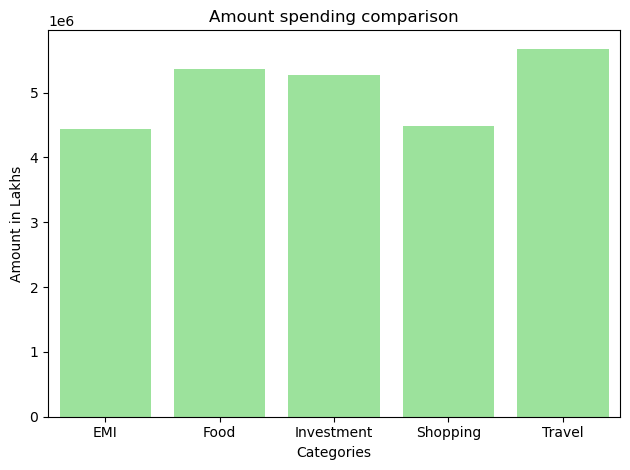

In [11]:
sns.barplot(x="Categories", y="Amount spent", data=df, color="lightgreen")
plt.xlabel("Categories")
plt.ylabel("Amount in Lakhs")
plt.title("Amount spending comparison")
plt.tight_layout()

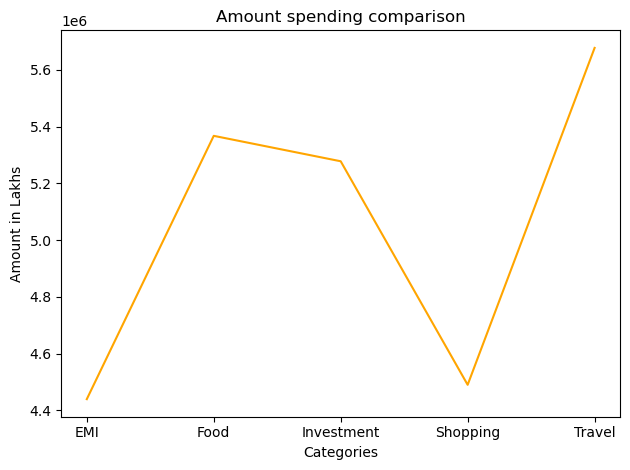

In [12]:
sns.lineplot(x="Categories", y="Amount spent", data=df, color="orange")
plt.xlabel("Categories")
plt.ylabel("Amount in Lakhs")
plt.title("Amount spending comparison")
plt.tight_layout()

In [16]:
import requests
import json
from IPython.display import display, Markdown

class Model:
    def __init__(self, api_key, link, model_name, message):
        self.api_key = api_key
        self.link = link
        self.model_name = model_name
        self.message = message

    def request(self):
        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json",
        }
        
        data_payload = {
            "model": self.model_name,
            "messages": [{"role": "user", "content": self.message}]
        }

        response = requests.post(
            url=self.link, 
            headers=headers, 
            data=json.dumps(data_payload)
        )

        if response.status_code != 200:
            print(f"Error {response.status_code}: {response.text}")
            return

        result = response.json()
        reply = result["choices"][0]["message"]["content"]
        
        # This renders the Markdown beautifully in Jupyter
        display(Markdown(reply))

        return reply

# Configuration
url = "https://openrouter.ai/api/v1/chat/completions"
API_key = "YOUR_OPENROUTER_API_KEY_HERE"
model_name = "openai/gpt-oss-20b:free"

# Assuming 'data' is your filtered DataFrame
# Using .to_string() helps the model read the table better than raw objects
Message = f'''Act as an elite report generation tool. Your task is to generate a report on the given data which should contain the comparison
of the users spendings in multiple categories, suggestions on spending and other important information. The data is based on the yearly spending of the user.
Data : {df}'''

# Execution
call = Model(API_key, url, model_name, Message)
content = call.request()

if content:
    with open("Insights.txt", "w", encoding="utf-8") as file:
        file.write(content)
    print("File made!")
else:
    print("Error occured")

# Executive Spending Report – FY 2024

**Prepared for:** *Your Personal Finance Advisor*  
**Prepared by:** *Elite Report Generation Tool*  
**Date:** 29 June 2026  

---

## 1. High‑Level Snapshot  

| Category | Annual Spend (₺) | % of Total | Monthly Avg. (₺) |
|----------|------------------|------------|------------------|
| EMI      | 4,439,711.32     | **17.6 %** | 369,809          |
| Food     | 5,367,643.75     | **21.3 %** | 447,280          |
| Investment | 5,278,014.54  | **20.9 %** | 439,834          |
| Shopping | 4,490,271.06     | **17.8 %** | 374,360          |
| Travel   | 5,677,529.29     | **22.5 %** | 473,127          |
| **Total** | **25,253,169.96** | 100 %     | **2,104,428**    |

> **Key Fact** – Your most significant outlays (Travel + Food) absorb **43.8 %** of your overall spending. The remaining 56.2 % is distributed fairly evenly across EMI, Investment, and Shopping.

---

## 2. Comparative Analysis  

| Rank | Category | Spend | % of Total | Difference to Next Category |
|------|----------|-------|------------|------------------------------|
| 1 | Travel | 5,677,529.29 | 22.5 % | ─ |
| 2 | Food | 5,367,643.75 | 21.3 % | 309 k |
| 3 | Investment | 5,278,014.54 | 20.9 % | 89 k |
| 4 | Shopping | 4,490,271.06 | 17.8 % | 355 k |
| 5 | EMI | 4,439,711.32 | 17.6 % | 351 k |

**Observations**

1. **Travel** leads by a comfortable margin, suggesting either a generous vacation budget or potential upgrades that could be streamlined.  
2. **Food** follows closely behind; the split between groceries and dining out is not provided but may warrant a deeper dive.  
3. **Investment** aligns with the recommended **20–25 %** of disposable income for long‑term growth—excellent compliance.  
4. **Shopping** and **EMI** are comparable; the buying cycle might overlap (e.g., premium seasonal apparel, retail promotion).  

---

## 3. Recommendations  

| Category | Current Position | Suggested Adjustment | Rationale |
|----------|------------------|----------------------|-----------|
| **Travel** | 22.5 % | Reduce to 18–20 % | Allocate up to 12–14 % more to emergencies or debt‑repayment. |
| **Food** | 21.3 % | Target 18–19 % | Consider meal‑planning, bulk purchasing, and curb‑side pick‑up to trim discretionary meals. |
| **Investment** | 20.9 % | Maintain or Increase | A +1 % boost can compound significantly over time. |
| **Shopping** | 17.8 % | Limit to 15 % | Channel allocated funds into high‑ROI categories or savings. |
| **EMI** | 17.6 % | Review lower‑interest alternatives | If the equity/disbursed amount is high, consider refinancing or consolidating. |
| **Cash Reserve** | **?** | Aim for 6‑month buffer | Ideal if your total monthly spend (≈ 2,104,428 ₺) is roughly 12 × your net income. |
| **Health/Insurance** | Not listed | Allocate 5–7 % | Ensure coverage tiers match income level. |

**Action Plan – First 90 Days**

1. **Audit Sub‑Categories** – Break down Travel and Food into sub‑categories (e.g., airfare vs. lodging; dining vs. groceries).  
2. **Set Monthly Limits** – Use a budgeting app to enforce the new percentage caps.  
3. **Automate Investments** – Re‑balance with a 60/40 equity‑debt split if appropriate.  
4. **Review EMI Terms** – Contact lenders, evaluate fixed vs. variable, and negotiate a refinance if a lower rate is available.  
5. **Emergency Fund Check** – Verify that your liquid reserves cover 3–6 months of the new, reduced monthly consumption level.

---

## 4. Other Important Information  

| Item | Details |
|------|---------|
| **Data Source** | Self‑reported annual summaries; no actual bank statements included. |
| **Assumptions** | No inflation adjustment, no tax impact considered, EMI represents loan repayments only. |
| **Potential Risks** | Over‑cautious cutting might reduce quality of life; conversely, under‑investing ignores compound growth. |
| **Future Tracking** | Align with quarterly reviews; monitor any lifestyle changes (marriage, children) that shift discretionary spending. |

---

## 5. Visual Summary (Recommended Format)

| Figure | Description |
|--------|-------------|
| **Stacked Bar Chart** | Total spend across categories; color‐code by % thresholds (15 %, 20 %, 25 %). |
| **Pie Chart** | Menu‑style breakdown; interactive drill‑down for sub‑categories. |
| **Trend Line** | If you have monthly data, plot a line for each category to spot seasonal spikes (e.g., travel peak). |

*If an automated platform is available, embed interactive dashboards capable of updating with future data streams.*

---

### Closing Remarks  

By anchoring your disposable income into a disciplined allocation—especially maintaining a healthy investment stance—you position yourself to meet both present expectations (quality travel, dining) and future security goals (retirement, emergency buffer). Execute the outlined action plan within 90 days, track outcomes monthly, and revisit in M+12 to fine‑tune your financial architecture.

*Prepared with precision by the Elite Report Generation Tool.*

File made!
